# Egocentric Boundary Representations (EBRs)

## Tutorial: Computing EBRs Following Alexander et al. (2020)

This notebook demonstrates how to compute **Egocentric Boundary Representations (EBRs)** - a method for analyzing how neurons encode the position of environmental boundaries relative to the animal's body.

### Reference
Alexander, A. S., Carstensen, L. C., Hinman, J. R., Raudies, F., Chapman, G. W., & Hasselmo, M. E. (2020).  
**Egocentric boundary vector tuning of the retrosplenial cortex.**  
*Science Advances*, 6(8), eaaz2322.

---

## What are EBRs?

An **EBR** (Egocentric Boundary Representation) is a 2D map showing neural firing rate as a function of:
- **Angle** (egocentric): Where is the boundary relative to the animal's heading?
  - 0°/360°: Directly ahead
  - 90°: To the left
  - 180°: Behind
  - 270°: To the right
- **Distance**: How far away is the boundary?

### Key Insight

Unlike allocentric spatial representations (e.g., place cells), EBRs are **body-centered**. They rotate with the animal, always representing space relative to "where I'm facing."

---

## Setup

First, install required packages and import the EBR module.

In [1]:
# Install packages
!pip install pynapple numpy scipy matplotlib -q

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pynapple as nap
from scipy.ndimage import gaussian_filter

# Import the EBR functions
# (In Colab, you'll need to upload the egocentric_boundary_representation.py file)
# For now, we'll define the key functions inline

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


---

## Method Overview: How EBRs are Computed

### Step-by-Step Process

#### 1. For Each Video Frame:

**A. Define egocentric rays**
- Cast rays at angles 0° to 360° (in 3° increments) relative to the animal's heading
- Each ray extends from the animal's position outward

**B. Find boundary intersections**
- For each ray, calculate where it intersects arena walls
- Compute the distance to intersection
- Only consider distances up to a maximum (typically 62.5 cm)

**C. Bin the boundaries**
- Each intersection gets assigned to an (angle, distance) bin
- Angle bins: 3° wide (120 bins total)
- Distance bins: 2.5 cm wide (25 bins for 62.5 cm max)

**D. Accumulate occupancy**
- Add time (Δt) to each bin containing a boundary
- This creates an **occupancy map**: "How long did I spend with a boundary at this egocentric position?"

#### 2. For Each Spike:

- Find the animal's position/heading when the spike occurred
- Compute boundary positions (same as Step 1)
- Add spike count to the corresponding bins
- This creates a **spike map**

#### 3. Compute Firing Rate:

$$\text{EBR}(\theta, d) = \frac{\text{Spike Map}(\theta, d)}{\text{Occupancy Map}(\theta, d)}$$

Where:
- $\theta$ = egocentric angle
- $d$ = distance to boundary

#### 4. Smooth:

- Apply 2D Gaussian smoothing (σ = 5 bins)
- Use circular boundary conditions for the angle dimension

---

### Mathematical Details

#### Ray-Wall Intersection

For a ray starting at $(x_0, y_0)$ with direction $(\cos\alpha, \sin\alpha)$ in allocentric coordinates:

$$\text{Ray: } \mathbf{P}(t) = (x_0, y_0) + t(\cos\alpha, \sin\alpha), \quad t \geq 0$$

For a wall segment from $(x_1, y_1)$ to $(x_2, y_2)$:

$$\text{Wall: } \mathbf{W}(s) = (x_1, y_1) + s(x_2 - x_1, y_2 - y_1), \quad 0 \leq s \leq 1$$

The intersection distance $t$ is found by solving:

$$t = \frac{(x_1 - x_0)(y_2 - y_1) - (y_1 - y_0)(x_2 - x_1)}{\cos\alpha(y_2 - y_1) - \sin\alpha(x_2 - x_1)}$$

#### Egocentric to Allocentric Conversion

If the animal faces direction $\theta_{head}$ (allocentric), an egocentric angle $\theta_{ego}$ corresponds to:

$$\theta_{allo} = \theta_{ego} + \theta_{head}$$

---

## Loading the Data

Let's load the sample session with head direction cells.

In [2]:
# Load NWB file
# Replace with your actual file path
!curl -sO https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/mouse_foraging/area-pos_sub-normalA3717_ses-201021_epoch-0.nwb
data_path = 'area-pos_sub-normalA3717_ses-201021_epoch-0.nwb'
session = nap.load_file(data_path)

print("✓ Session loaded")
print(f"Session: {session.name}")
print(f"Available data: {list(session.keys())}")

✓ Session loaded
Session: area-pos_sub-normalA3717_ses-201021_epoch-0
Available data: ['units', 'epoch', 'z', 'y', 'x', 'rz', 'ry', 'rx', 'distance_border']


In [16]:
# Extract behavioral data
x_pos = np.array(session['x'].values)  # X position (meters)
y_pos = np.array(session['z'].values)  # Y position (meters)
timestamps = np.array(session['x'].index.values)  # Time (seconds)

# Head direction (convert to radians, normalize to [0, 2π])
yaw = np.array(session['ry'].values)  # Yaw angle (degrees)
head_dir = np.deg2rad(yaw % 360)  # Convert to radians

print(f"Number of frames: {len(x_pos)}")
print(f"Duration: {timestamps[-1] - timestamps[0]:.2f} seconds")
print(f"Sampling rate: ~{len(timestamps) / (timestamps[-1] - timestamps[0]):.1f} Hz")

Number of frames: 180407
Duration: 1803.96 seconds
Sampling rate: ~100.0 Hz


In [17]:
# Define arena boundaries
# These are extracted from the session description
arena_bounds = {
    'x_min': -0.2385824,
    'x_max': 0.6119824,
    'y_min': -0.0771792,
    'y_max': 0.7785472
}

print("Arena boundaries (meters):")
for key, val in arena_bounds.items():
    print(f"  {key}: {val:.4f}")

# Arena dimensions
arena_width = arena_bounds['x_max'] - arena_bounds['x_min']
arena_height = arena_bounds['y_max'] - arena_bounds['y_min']
print(f"\nArena size: {arena_width:.2f} m × {arena_height:.2f} m")

Arena boundaries (meters):
  x_min: -0.2386
  x_max: 0.6120
  y_min: -0.0772
  y_max: 0.7785

Arena size: 0.85 m × 0.86 m


In [ ]:
# Get neural data
units = session['units']

# Filter for HD cells if classification available
if 'hd_type' in units.metadata.columns:
    hd_units = units.getby_category('hd_type')[1]
    print(f"Number of HD cells: {len(hd_units)}")
else:
    hd_units = units
    print(f"Number of neurons: {len(hd_units)}")


Number of HD cells: 59

Example neuron: 63
Number of spikes: 13098
Mean firing rate: 7.26 Hz



Example neuron: 63
Number of spikes: 13098
Mean firing rate: 7.26 Hz


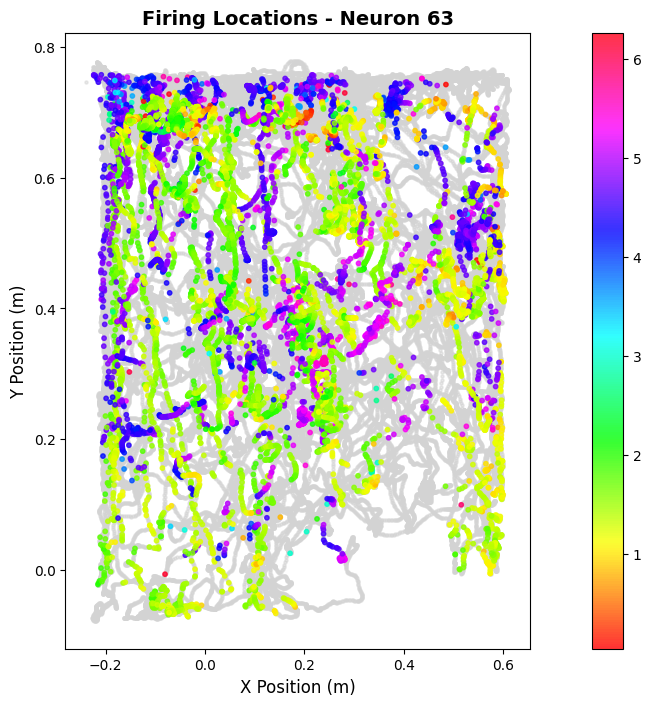

In [45]:

# Select an example neuron for analysis
example_neuron = list(hd_units.keys())[43]
spike_times = hd_units[example_neuron].index.values

print(f"\nExample neuron: {example_neuron}")
print(f"Number of spikes: {len(spike_times)}")
print(f"Mean firing rate: {len(spike_times) / (timestamps[-1] - timestamps[0]):.2f} Hz")
# plot the location when the neuron fires with wall boundaries plotted, and color by the head direction at that moment
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x_pos, y_pos, s=5, color='lightgray', label='Position', alpha=0.5)
spike_x = []
spike_y = []
spike_colors = []
for spike_time in spike_times:

    frame_idx = np.argmin(np.abs(timestamps - spike_time))
    spike_x.append(x_pos[frame_idx])
    spike_y.append(y_pos[frame_idx])
    spike_colors.append(head_dir[frame_idx])
heatmap = ax.scatter(spike_x, spike_y, s=10, c=spike_colors, label='Spikes', alpha=0.8,cmap='hsv')
ax.set_xlabel('X Position (m)', fontsize=12)
ax.set_ylabel('Y Position (m)', fontsize=12)
ax.set_title(f'Firing Locations - Neuron {example_neuron}', fontsize=14
                , fontweight='bold')
# plot the colorbar for head direction
cbar = plt.colorbar(heatmap, ax=ax, pad=0.1)

---

## Computing the EBR

Now we'll implement the EBR computation. This is the core algorithm from Alexander et al. (2020).

In [8]:
def ray_segment_intersection(x0, y0, dx, dy, x1, y1, x2, y2):
    """
    Find intersection between a ray and a line segment.
    
    Returns distance to intersection, or None if no valid intersection.
    """
    seg_dx = x2 - x1
    seg_dy = y2 - y1
    
    # Check if parallel
    denom = dx * seg_dy - dy * seg_dx
    if abs(denom) < 1e-10:
        return None
    
    # Solve for intersection parameters
    t = ((x1 - x0) * seg_dy - (y1 - y0) * seg_dx) / denom
    s = ((x1 - x0) * dy - (y1 - y0) * dx) / denom
    
    # Check validity
    if t >= 0 and 0 <= s <= 1:
        return t * np.sqrt(dx**2 + dy**2)
    
    return None


def find_boundary_intersections(x, y, head_dir, arena_bounds, 
                                angle_bins=120, distance_bins=25,
                                max_distance=0.625):
    """
    For a single position/heading, find where egocentric rays intersect boundaries.
    
    Returns a 2D array (angle_bins × distance_bins) indicating which bins contain boundaries.
    """
    # Egocentric angles (0° = ahead, 90° = left, etc.)
    ego_angles = np.linspace(0, 2*np.pi, angle_bins, endpoint=False)
    
    # Convert to allocentric
    allo_angles = ego_angles + head_dir
    
    # Distance bins
    dist_edges = np.linspace(0, max_distance, distance_bins + 1)
    
    # Initialize boundary map
    boundary_map = np.zeros((angle_bins, distance_bins))
    
    # Define arena walls
    walls = [
        (arena_bounds['x_min'], arena_bounds['y_max'], 
         arena_bounds['x_max'], arena_bounds['y_max']),  # North
        (arena_bounds['x_min'], arena_bounds['y_min'], 
         arena_bounds['x_max'], arena_bounds['y_min']),  # South
        (arena_bounds['x_max'], arena_bounds['y_min'], 
         arena_bounds['x_max'], arena_bounds['y_max']),  # East
        (arena_bounds['x_min'], arena_bounds['y_min'], 
         arena_bounds['x_min'], arena_bounds['y_max'])   # West
    ]
    
    # For each angle
    for angle_idx, allo_angle in enumerate(allo_angles):
        ray_dx = np.cos(allo_angle)
        ray_dy = np.sin(allo_angle)
        
        # Find closest wall intersection
        min_dist = np.inf
        
        for x1, y1, x2, y2 in walls:
            dist = ray_segment_intersection(x, y, ray_dx, ray_dy, x1, y1, x2, y2)
            if dist is not None and dist <= max_distance:
                min_dist = min(min_dist, dist)
        
        # Assign to distance bin
        if min_dist < np.inf:
            dist_idx = np.searchsorted(dist_edges, min_dist) - 1
            if 0 <= dist_idx < distance_bins:
                boundary_map[angle_idx, dist_idx] = 1
    
    return boundary_map

print("✓ Helper functions defined")

✓ Helper functions defined


In [9]:
def compute_ebr(x_pos, y_pos, head_dir, spike_times, timestamps,
                arena_bounds, angle_bins=120, distance_bins=25,
                max_distance=0.625, smooth_sigma=5):
    """
    Compute Egocentric Boundary Representation (EBR) following Alexander et al. (2020).
    
    Parameters:
    -----------
    x_pos, y_pos : array
        Position over time (meters)
    head_dir : array
        Head direction over time (radians)
    spike_times : array
        Neural spike times (seconds)
    timestamps : array
        Time of each position sample (seconds)
    arena_bounds : dict
        Arena boundaries
    angle_bins : int
        Number of angular bins (default: 120 for 3° bins)
    distance_bins : int
        Number of distance bins (default: 25 for 2.5cm bins)
    max_distance : float
        Maximum distance to consider (meters)
    smooth_sigma : float
        Gaussian smoothing sigma
    
    Returns:
    --------
    ebr : 2D array
        Firing rate (Hz) at each (angle, distance) bin
    occupancy_map : 2D array
        Time spent (seconds) in each bin
    spike_map : 2D array
        Number of spikes in each bin
    angle_centers : array
        Angle bin centers (degrees)
    distance_centers : array
        Distance bin centers (meters)
    """
    n_frames = len(x_pos)
    
    # Initialize maps
    occupancy_map = np.zeros((angle_bins, distance_bins))
    spike_map = np.zeros((angle_bins, distance_bins))
    
    # Time per frame
    dt = np.mean(np.diff(timestamps))
    
    print(f"Computing EBR for {n_frames} frames and {len(spike_times)} spikes...")
    print(f"  Angle bins: {angle_bins} (bin width: {360/angle_bins:.1f}°)")
    print(f"  Distance bins: {distance_bins} (bin width: {max_distance/distance_bins*100:.1f} cm)")
    
    # STEP 1: Compute occupancy map
    print("\n[1/3] Computing occupancy map...")
    for frame_idx in range(n_frames):
        if frame_idx % 1000 == 0:
            print(f"      Frame {frame_idx}/{n_frames} ({100*frame_idx/n_frames:.1f}%)")
        
        boundary_map = find_boundary_intersections(
            x_pos[frame_idx], y_pos[frame_idx], head_dir[frame_idx],
            arena_bounds, angle_bins, distance_bins, max_distance
        )
        
        occupancy_map += boundary_map * dt
    
    # STEP 2: Compute spike map
    print("\n[2/3] Computing spike map...")
    for spike_idx, spike_time in enumerate(spike_times):
        if spike_idx % 100 == 0:
            print(f"      Spike {spike_idx}/{len(spike_times)} ({100*spike_idx/len(spike_times):.1f}%)")
        
        # Find closest frame
        frame_idx = np.argmin(np.abs(timestamps - spike_time))
        
        boundary_map = find_boundary_intersections(
            x_pos[frame_idx], y_pos[frame_idx], head_dir[frame_idx],
            arena_bounds, angle_bins, distance_bins, max_distance
        )
        
        spike_map += boundary_map
    
    # STEP 3: Compute firing rate
    print("\n[3/3] Computing firing rates...")
    ebr = np.zeros_like(occupancy_map)
    valid_bins = occupancy_map > 0
    ebr[valid_bins] = spike_map[valid_bins] / occupancy_map[valid_bins]
    
    print(f"      Valid bins: {np.sum(valid_bins)} / {ebr.size} ({100*np.sum(valid_bins)/ebr.size:.1f}%)")
    print(f"      Max firing rate: {ebr.max():.2f} Hz")
    
    # STEP 4: Apply smoothing
    if smooth_sigma > 0:
        print(f"\nApplying Gaussian smoothing (σ={smooth_sigma})...")
        # Pad angle dimension for circular boundary
        ebr_padded = np.vstack([ebr[-smooth_sigma:], ebr, ebr[:smooth_sigma]])
        ebr_smoothed = gaussian_filter(ebr_padded, sigma=smooth_sigma, mode='constant')
        ebr = ebr_smoothed[smooth_sigma:-smooth_sigma]
    
    # Create bin centers
    angle_centers = np.linspace(0, 360, angle_bins, endpoint=False)
    dist_edges = np.linspace(0, max_distance, distance_bins + 1)
    distance_centers = (dist_edges[:-1] + dist_edges[1:]) / 2
    
    print("\n✓ EBR computation complete!")
    
    return ebr, occupancy_map, spike_map, angle_centers, distance_centers

print("✓ EBR computation function defined")

✓ EBR computation function defined


### Run the EBR Computation

This will take a few minutes depending on your data size.

In [49]:
# Compute EBR for the example neuron
ebr, occupancy_map, spike_map, angle_centers, distance_centers = compute_ebr(
    x_pos=x_pos,
    y_pos=y_pos,
    head_dir=head_dir,
    spike_times=spike_times,
    timestamps=timestamps,
    arena_bounds=arena_bounds,
    angle_bins=40,        # 3° bins
    distance_bins=25,      # 2.5 cm bins
    max_distance=0.3,    # 62.5 cm max
    smooth_sigma=5         # Gaussian smoothing
)

Computing EBR for 180407 frames and 13098 spikes...
  Angle bins: 40 (bin width: 9.0°)
  Distance bins: 25 (bin width: 1.2 cm)

[1/3] Computing occupancy map...
      Frame 0/180407 (0.0%)
      Frame 1000/180407 (0.6%)
      Frame 2000/180407 (1.1%)
      Frame 3000/180407 (1.7%)
      Frame 4000/180407 (2.2%)
      Frame 5000/180407 (2.8%)
      Frame 6000/180407 (3.3%)
      Frame 7000/180407 (3.9%)
      Frame 8000/180407 (4.4%)
      Frame 9000/180407 (5.0%)
      Frame 10000/180407 (5.5%)
      Frame 11000/180407 (6.1%)
      Frame 12000/180407 (6.7%)
      Frame 13000/180407 (7.2%)
      Frame 14000/180407 (7.8%)
      Frame 15000/180407 (8.3%)
      Frame 16000/180407 (8.9%)
      Frame 17000/180407 (9.4%)
      Frame 18000/180407 (10.0%)
      Frame 19000/180407 (10.5%)
      Frame 20000/180407 (11.1%)
      Frame 21000/180407 (11.6%)
      Frame 22000/180407 (12.2%)
      Frame 23000/180407 (12.7%)
      Frame 24000/180407 (13.3%)
      Frame 25000/180407 (13.9%)
      Frame 

---

## Visualizing the Results

Let's create multiple visualizations to understand the EBR.

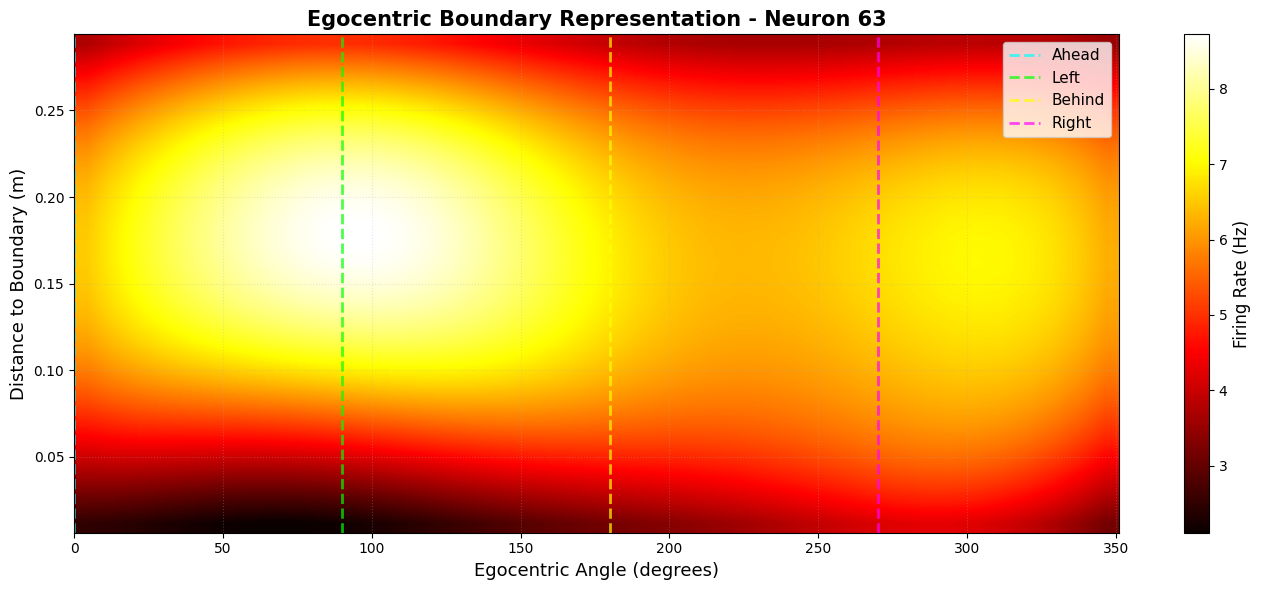

In [50]:
# Plot 1: EBR in Cartesian coordinates
fig, ax = plt.subplots(figsize=(14, 6))

extent = [angle_centers[0], angle_centers[-1], 
          distance_centers[0], distance_centers[-1]]

im = ax.imshow(ebr.T, origin='lower', aspect='auto', 
               extent=extent, cmap='hot', interpolation='bilinear')

# Add reference lines
ax.axvline(0, color='cyan', linestyle='--', alpha=0.7, linewidth=2, label='Ahead')
ax.axvline(90, color='lime', linestyle='--', alpha=0.7, linewidth=2, label='Left')
ax.axvline(180, color='yellow', linestyle='--', alpha=0.7, linewidth=2, label='Behind')
ax.axvline(270, color='magenta', linestyle='--', alpha=0.7, linewidth=2, label='Right')

ax.set_xlabel('Egocentric Angle (degrees)', fontsize=13)
ax.set_ylabel('Distance to Boundary (m)', fontsize=13)
ax.set_title(f'Egocentric Boundary Representation - Neuron {example_neuron}', 
             fontsize=15, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Firing Rate (Hz)', fontsize=12)

ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

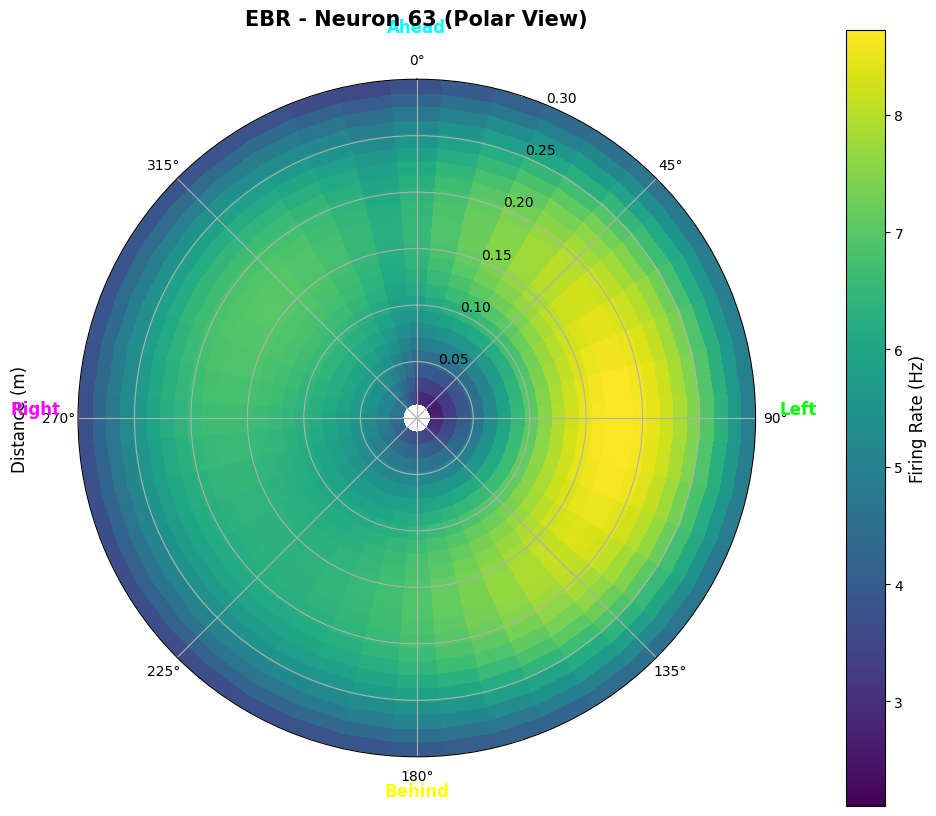

In [51]:
# Plot 2: EBR in Polar coordinates (more intuitive!)
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Convert to radians for polar plot
angles_rad = np.deg2rad(angle_centers)
A, R = np.meshgrid(angles_rad, distance_centers)

# Plot
im = ax.pcolormesh(A, R, ebr.T, cmap='viridis', shading='auto')

# Styling
ax.set_theta_zero_location('N')  # 0° at top (ahead)
ax.set_theta_direction(-1)        # Clockwise (like compass)
ax.set_title(f'EBR - Neuron {example_neuron} (Polar View)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Distance (m)', labelpad=35, fontsize=12)

# Add direction labels
ax.text(0, distance_centers[-1] * 1.15, 'Ahead', 
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='cyan')
ax.text(np.pi/2, distance_centers[-1] * 1.15, 'Left', 
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='lime')
ax.text(np.pi, distance_centers[-1] * 1.15, 'Behind', 
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='yellow')
ax.text(3*np.pi/2, distance_centers[-1] * 1.15, 'Right', 
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='magenta')

# Colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.1, shrink=0.8)
cbar.set_label('Firing Rate (Hz)', fontsize=12)

plt.tight_layout()
plt.show()

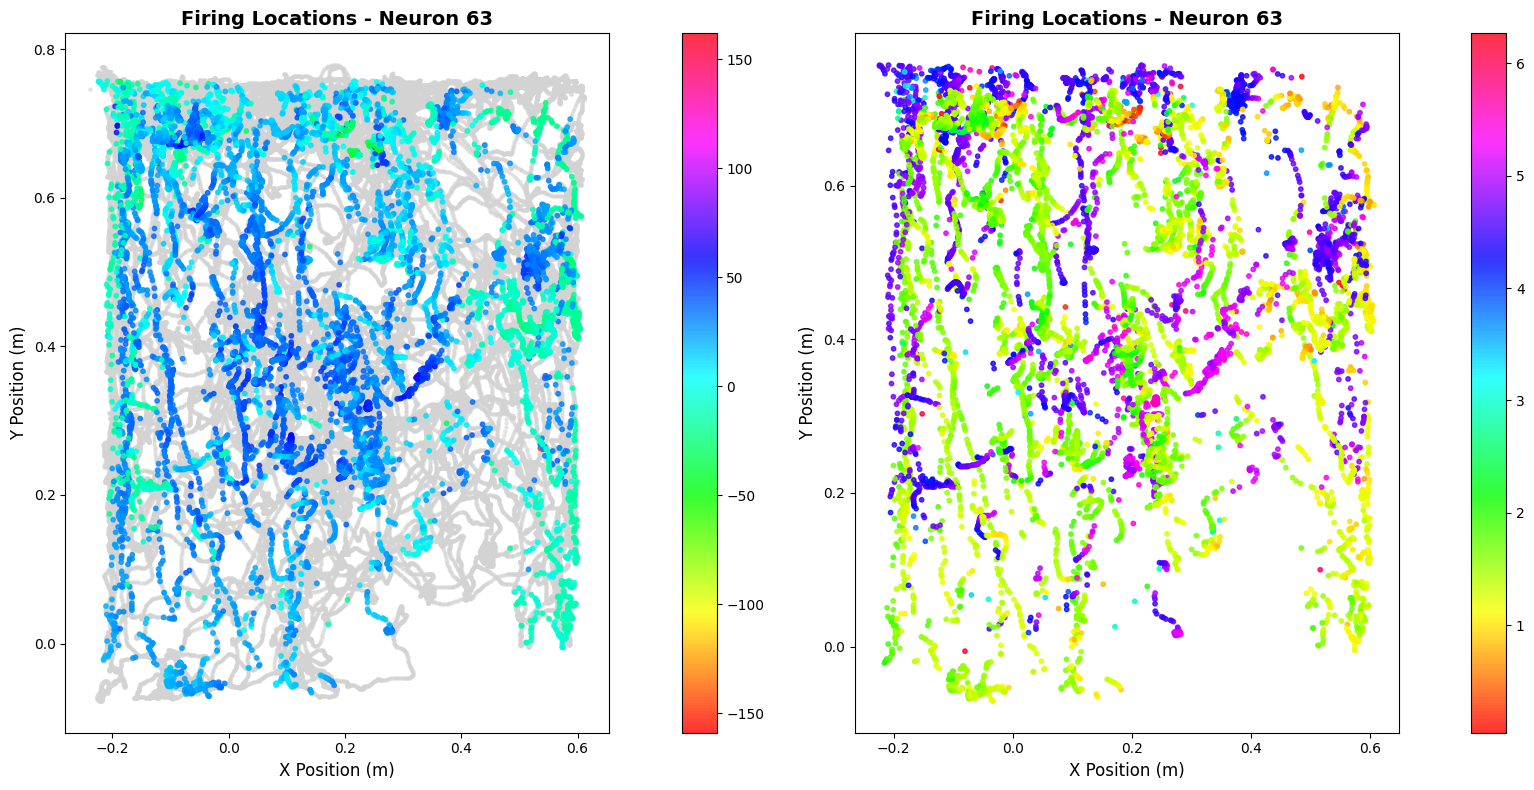

In [47]:
# plot the location when the neuron fires with wall boundaries plotted, and color by the head direction at that moment
fig, axs = plt.subplots(1,2, figsize=(16, 8))
axs[0].scatter(x_pos, y_pos, s=5, color='lightgray', label='Position', alpha=0.5)
spike_x = []
spike_y = []
spike_colors = []
pitch_value = np.array(session['rx'].values)  # Pitch angle (degrees)
for spike_time in spike_times:

    frame_idx = np.argmin(np.abs(timestamps - spike_time))
    spike_x.append(x_pos[frame_idx])
    spike_y.append(y_pos[frame_idx])
    spike_colors.append(pitch_value[frame_idx])
heatmap = axs[0].scatter(spike_x, spike_y, s=10, c=spike_colors, label='Spikes', alpha=0.8,cmap='hsv')
axs[0].set_xlabel('X Position (m)', fontsize=12)
axs[0].set_ylabel('Y Position (m)', fontsize=12)
axs[0].set_title(f'Firing Locations - Neuron {example_neuron}', fontsize=14
                , fontweight='bold')
# plot the colorbar for pitch angle
cbar = plt.colorbar(heatmap, ax=axs[0], pad=0.1)

# for yaw head direction
spike_colors = []
for spike_time in spike_times:
    
    frame_idx = np.argmin(np.abs(timestamps - spike_time))
    spike_colors.append(head_dir[frame_idx])
heatmap = axs[1].scatter(spike_x, spike_y, s=10, c=spike_colors, label='Spikes', alpha=0.8,cmap='hsv')
axs[1].set_xlabel('X Position (m)', fontsize=12)
axs[1].set_ylabel('Y Position (m)', fontsize=12)
axs[1].set_title(f'Firing Locations - Neuron {example_neuron}', fontsize=14
                , fontweight='bold')
# plot the colorbar for head direction
cbar = plt.colorbar(heatmap, ax=axs[1], pad=0.1)
plt.tight_layout()
plt.show()

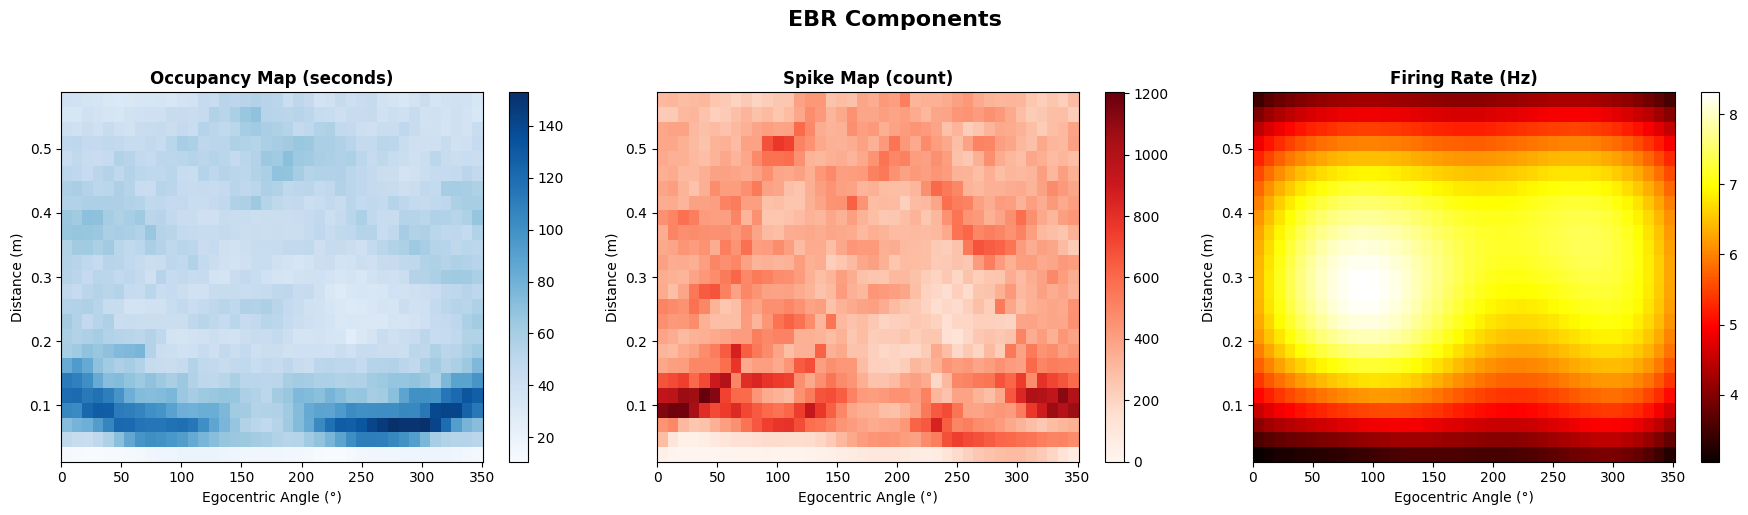


Interpretation:
- Occupancy: Where boundaries were located during the session
- Spikes: Where the neuron fired relative to boundaries
- Firing Rate: Occupancy-normalized neural response


In [48]:
# Plot 3: Component maps (occupancy, spikes, firing rate)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Occupancy
im1 = axes[0].imshow(occupancy_map.T, origin='lower', aspect='auto',
                     extent=extent, cmap='Blues')
axes[0].set_xlabel('Egocentric Angle (°)')
axes[0].set_ylabel('Distance (m)')
axes[0].set_title('Occupancy Map (seconds)', fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# Spikes
im2 = axes[1].imshow(spike_map.T, origin='lower', aspect='auto',
                     extent=extent, cmap='Reds')
axes[1].set_xlabel('Egocentric Angle (°)')
axes[1].set_ylabel('Distance (m)')
axes[1].set_title('Spike Map (count)', fontweight='bold')
plt.colorbar(im2, ax=axes[1])

# Firing rate
im3 = axes[2].imshow(ebr.T, origin='lower', aspect='auto',
                     extent=extent, cmap='hot')
axes[2].set_xlabel('Egocentric Angle (°)')
axes[2].set_ylabel('Distance (m)')
axes[2].set_title('Firing Rate (Hz)', fontweight='bold')
plt.colorbar(im3, ax=axes[2])

plt.suptitle('EBR Components', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Occupancy: Where boundaries were located during the session")
print("- Spikes: Where the neuron fired relative to boundaries")
print("- Firing Rate: Occupancy-normalized neural response")

### Compute Summary Statistics

In [14]:
# Find peak location
peak_idx = np.unravel_index(np.argmax(ebr), ebr.shape)
peak_angle = angle_centers[peak_idx[0]]
peak_distance = distance_centers[peak_idx[1]]
peak_rate = ebr[peak_idx]

# Coverage (fraction of bins with data)
valid_bins = occupancy_map > 0.1
coverage = np.sum(valid_bins) / ebr.size

# Mean firing rate (in valid bins)
mean_rate = np.mean(ebr[valid_bins])

# Sparsity measure
valid_rates = ebr[valid_bins]
sparsity = mean_rate**2 / np.mean(valid_rates**2) if len(valid_rates) > 0 else 0

print("=" * 60)
print(f"EBR STATISTICS - Neuron {example_neuron}")
print("=" * 60)
print(f"Peak firing rate:     {peak_rate:.2f} Hz")
print(f"Peak location:        {peak_angle:.1f}° @ {peak_distance*100:.1f} cm")
print(f"Mean firing rate:     {mean_rate:.2f} Hz")
print(f"Coverage:             {coverage*100:.1f}% of bins")
print(f"Sparsity:             {sparsity:.3f}")
print("=" * 60)

print("\nInterpretation:")
print(f"This neuron fires maximally when a boundary is {peak_distance*100:.0f} cm away")
print(f"at an angle of {peak_angle:.0f}° (egocentric).")

if 0 <= peak_angle < 45 or 315 < peak_angle <= 360:
    direction = "ahead"
elif 45 <= peak_angle < 135:
    direction = "to the left"
elif 135 <= peak_angle < 225:
    direction = "behind"
else:
    direction = "to the right"

print(f"In other words: this cell prefers boundaries {direction}.")

EBR STATISTICS - Neuron 0
Peak firing rate:     2.00 Hz
Peak location:        162.0° @ 38.8 cm
Mean firing rate:     1.07 Hz
Coverage:             99.7% of bins
Sparsity:             0.873

Interpretation:
This neuron fires maximally when a boundary is 39 cm away
at an angle of 162° (egocentric).
In other words: this cell prefers boundaries behind.


---

## Analyzing Multiple Neurons

Let's compute EBRs for all HD cells and compare them.

In [ ]:
# Compute EBRs for all neurons (or first 10 for speed)
n_neurons_to_analyze = min(10, len(hd_units))
neuron_ids = list(hd_units.keys())[:n_neurons_to_analyze]

ebrs = {}
ebr_stats = {}

print(f"Computing EBRs for {n_neurons_to_analyze} neurons...\n")

for i, neuron_id in enumerate(neuron_ids):
    print(f"\n{'='*60}")
    print(f"Neuron {i+1}/{n_neurons_to_analyze}: {neuron_id}")
    print(f"{'='*60}")
    
    spikes = hd_units[neuron_id].index.values
    
    ebr_data = compute_ebr(
        x_pos, y_pos, head_dir, spikes, timestamps,
        arena_bounds, angle_bins=120, distance_bins=25,
        max_distance=0.625, smooth_sigma=5
    )
    
    ebrs[neuron_id] = ebr_data
    
    # Compute stats
    ebr_map = ebr_data[0]
    occ_map = ebr_data[1]
    peak_idx = np.unravel_index(np.argmax(ebr_map), ebr_map.shape)
    
    ebr_stats[neuron_id] = {
        'peak_rate': ebr_map[peak_idx],
        'peak_angle': angle_centers[peak_idx[0]],
        'peak_distance': distance_centers[peak_idx[1]],
        'mean_rate': np.mean(ebr_map[occ_map > 0.1])
    }

print("\n" + "="*60)
print("✓ All EBRs computed!")
print("="*60)

In [ ]:
# Visualize all EBRs
n_cols = 5
n_rows = int(np.ceil(n_neurons_to_analyze / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows),
                         subplot_kw=dict(projection='polar'))
axes = axes.flatten()

for i, neuron_id in enumerate(neuron_ids):
    ebr_map = ebrs[neuron_id][0]
    angles_rad = np.deg2rad(angle_centers)
    A, R = np.meshgrid(angles_rad, distance_centers)
    
    ax = axes[i]
    im = ax.pcolormesh(A, R, ebr_map.T, cmap='hot', shading='auto')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    
    stats = ebr_stats[neuron_id]
    ax.set_title(f'Neuron {neuron_id}\nPeak: {stats["peak_rate"]:.1f} Hz @ '
                 f'{stats["peak_angle"]:.0f}°', fontsize=10)

# Remove extra subplots
for i in range(n_neurons_to_analyze, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Egocentric Boundary Representations - Population', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Population Statistics

In [ ]:
# Analyze population preferences
import pandas as pd

stats_df = pd.DataFrame(ebr_stats).T

print("Population Statistics:")
print("=" * 60)
print(stats_df.describe())
print("=" * 60)

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Peak angles
axes[0].hist(stats_df['peak_angle'], bins=12, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Peak Angle (degrees)')
axes[0].set_ylabel('Number of Neurons')
axes[0].set_title('Distribution of Preferred Angles')
axes[0].axvline(90, color='r', linestyle='--', label='Left')
axes[0].axvline(270, color='b', linestyle='--', label='Right')
axes[0].legend()

# Peak distances
axes[1].hist(stats_df['peak_distance']*100, bins=10, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Peak Distance (cm)')
axes[1].set_ylabel('Number of Neurons')
axes[1].set_title('Distribution of Preferred Distances')

# Peak rates
axes[2].hist(stats_df['peak_rate'], bins=10, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('Peak Firing Rate (Hz)')
axes[2].set_ylabel('Number of Neurons')
axes[2].set_title('Distribution of Peak Rates')

plt.suptitle('Population-Level EBR Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Summary & Interpretation

### What We Computed

We successfully implemented the **Egocentric Boundary Representation (EBR)** method from Alexander et al. (2020). This involved:

1. **Ray casting** from the animal's position in egocentric directions
2. **Finding intersections** with arena boundaries
3. **Binning** boundary locations in (angle, distance) space
4. **Computing occupancy** (time spent with boundaries at each location)
5. **Counting spikes** at each boundary location
6. **Calculating firing rates** (spikes / occupancy)
7. **Smoothing** with a 2D Gaussian filter

### What the EBR Tells Us

The EBR reveals how neurons encode environmental boundaries in **body-centered coordinates**:

- **Angle preference**: Does the cell prefer boundaries ahead, behind, left, or right?
- **Distance tuning**: Does the cell prefer near or far boundaries?
- **Spatial coding**: Is the representation allocentric (world-fixed) or egocentric (body-fixed)?

### Key Findings from Alexander et al. (2020)

The original paper found that **retrosplenial cortex (RSC)** neurons:

1. Encode boundaries in **egocentric coordinates**
2. Show **diverse tuning profiles** (different cells prefer different angles/distances)
3. Maintain stable representations during movement
4. May support **spatial navigation** by providing self-centered boundary information

### Comparison to Other Spatial Cells

- **Place cells**: Encode allocentric position ("I am here")
- **Grid cells**: Encode allocentric position in regular patterns
- **Head direction cells**: Encode allocentric heading ("I'm facing north")
- **Border/boundary cells**: Encode distance to walls (allocentric)
- **EBR neurons**: Encode boundary location **relative to body** (egocentric)

### Why This Matters

Egocentric representations are crucial for:
- **Navigation**: "Turn left when the wall is 20 cm to my right"
- **Obstacle avoidance**: Body-centered boundaries guide movement
- **Coordinate transforms**: Bridging sensory (egocentric) and spatial (allocentric) maps

---

## Next Steps

### Further Analyses You Can Do:

1. **Compare to head direction tuning**: Do cells with strong EBR tuning also show HD tuning?
2. **Movement direction vs. head direction**: Recompute EBRs using movement direction instead
3. **State dependence**: Do EBRs change during running vs. stationary periods?
4. **Temporal stability**: Split session in half and compare EBRs
5. **Population decoding**: Can you decode animal's position relative to boundaries from population activity?

### Extensions:

- Try different arena shapes (circular, irregular)
- Add internal obstacles and see how they're represented
- Compare across brain regions
- Test in virtual vs. real environments

---

## References

1. **Alexander et al. (2020)**. Egocentric boundary vector tuning of the retrosplenial cortex. *Science Advances*, 6(8), eaaz2322.

2. **Lever et al. (2009)**. Boundary Vector Cells in the Subiculum of the Hippocampal Formation. *Journal of Neuroscience*, 29(31), 9771-9777.

3. **Solstad et al. (2008)**. Representation of geometric borders in the entorhinal cortex. *Science*, 322(5909), 1865-1868.

---

**Congratulations!** You've successfully implemented and analyzed Egocentric Boundary Representations! 🎉